In [33]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split, TensorDataset
import torch.nn.functional as torch_F # avoid import problems becasue F is used as a variable

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import json

import sys
sys.path.append('../src')

from preprocessing import *
from models import  *
from utils import *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

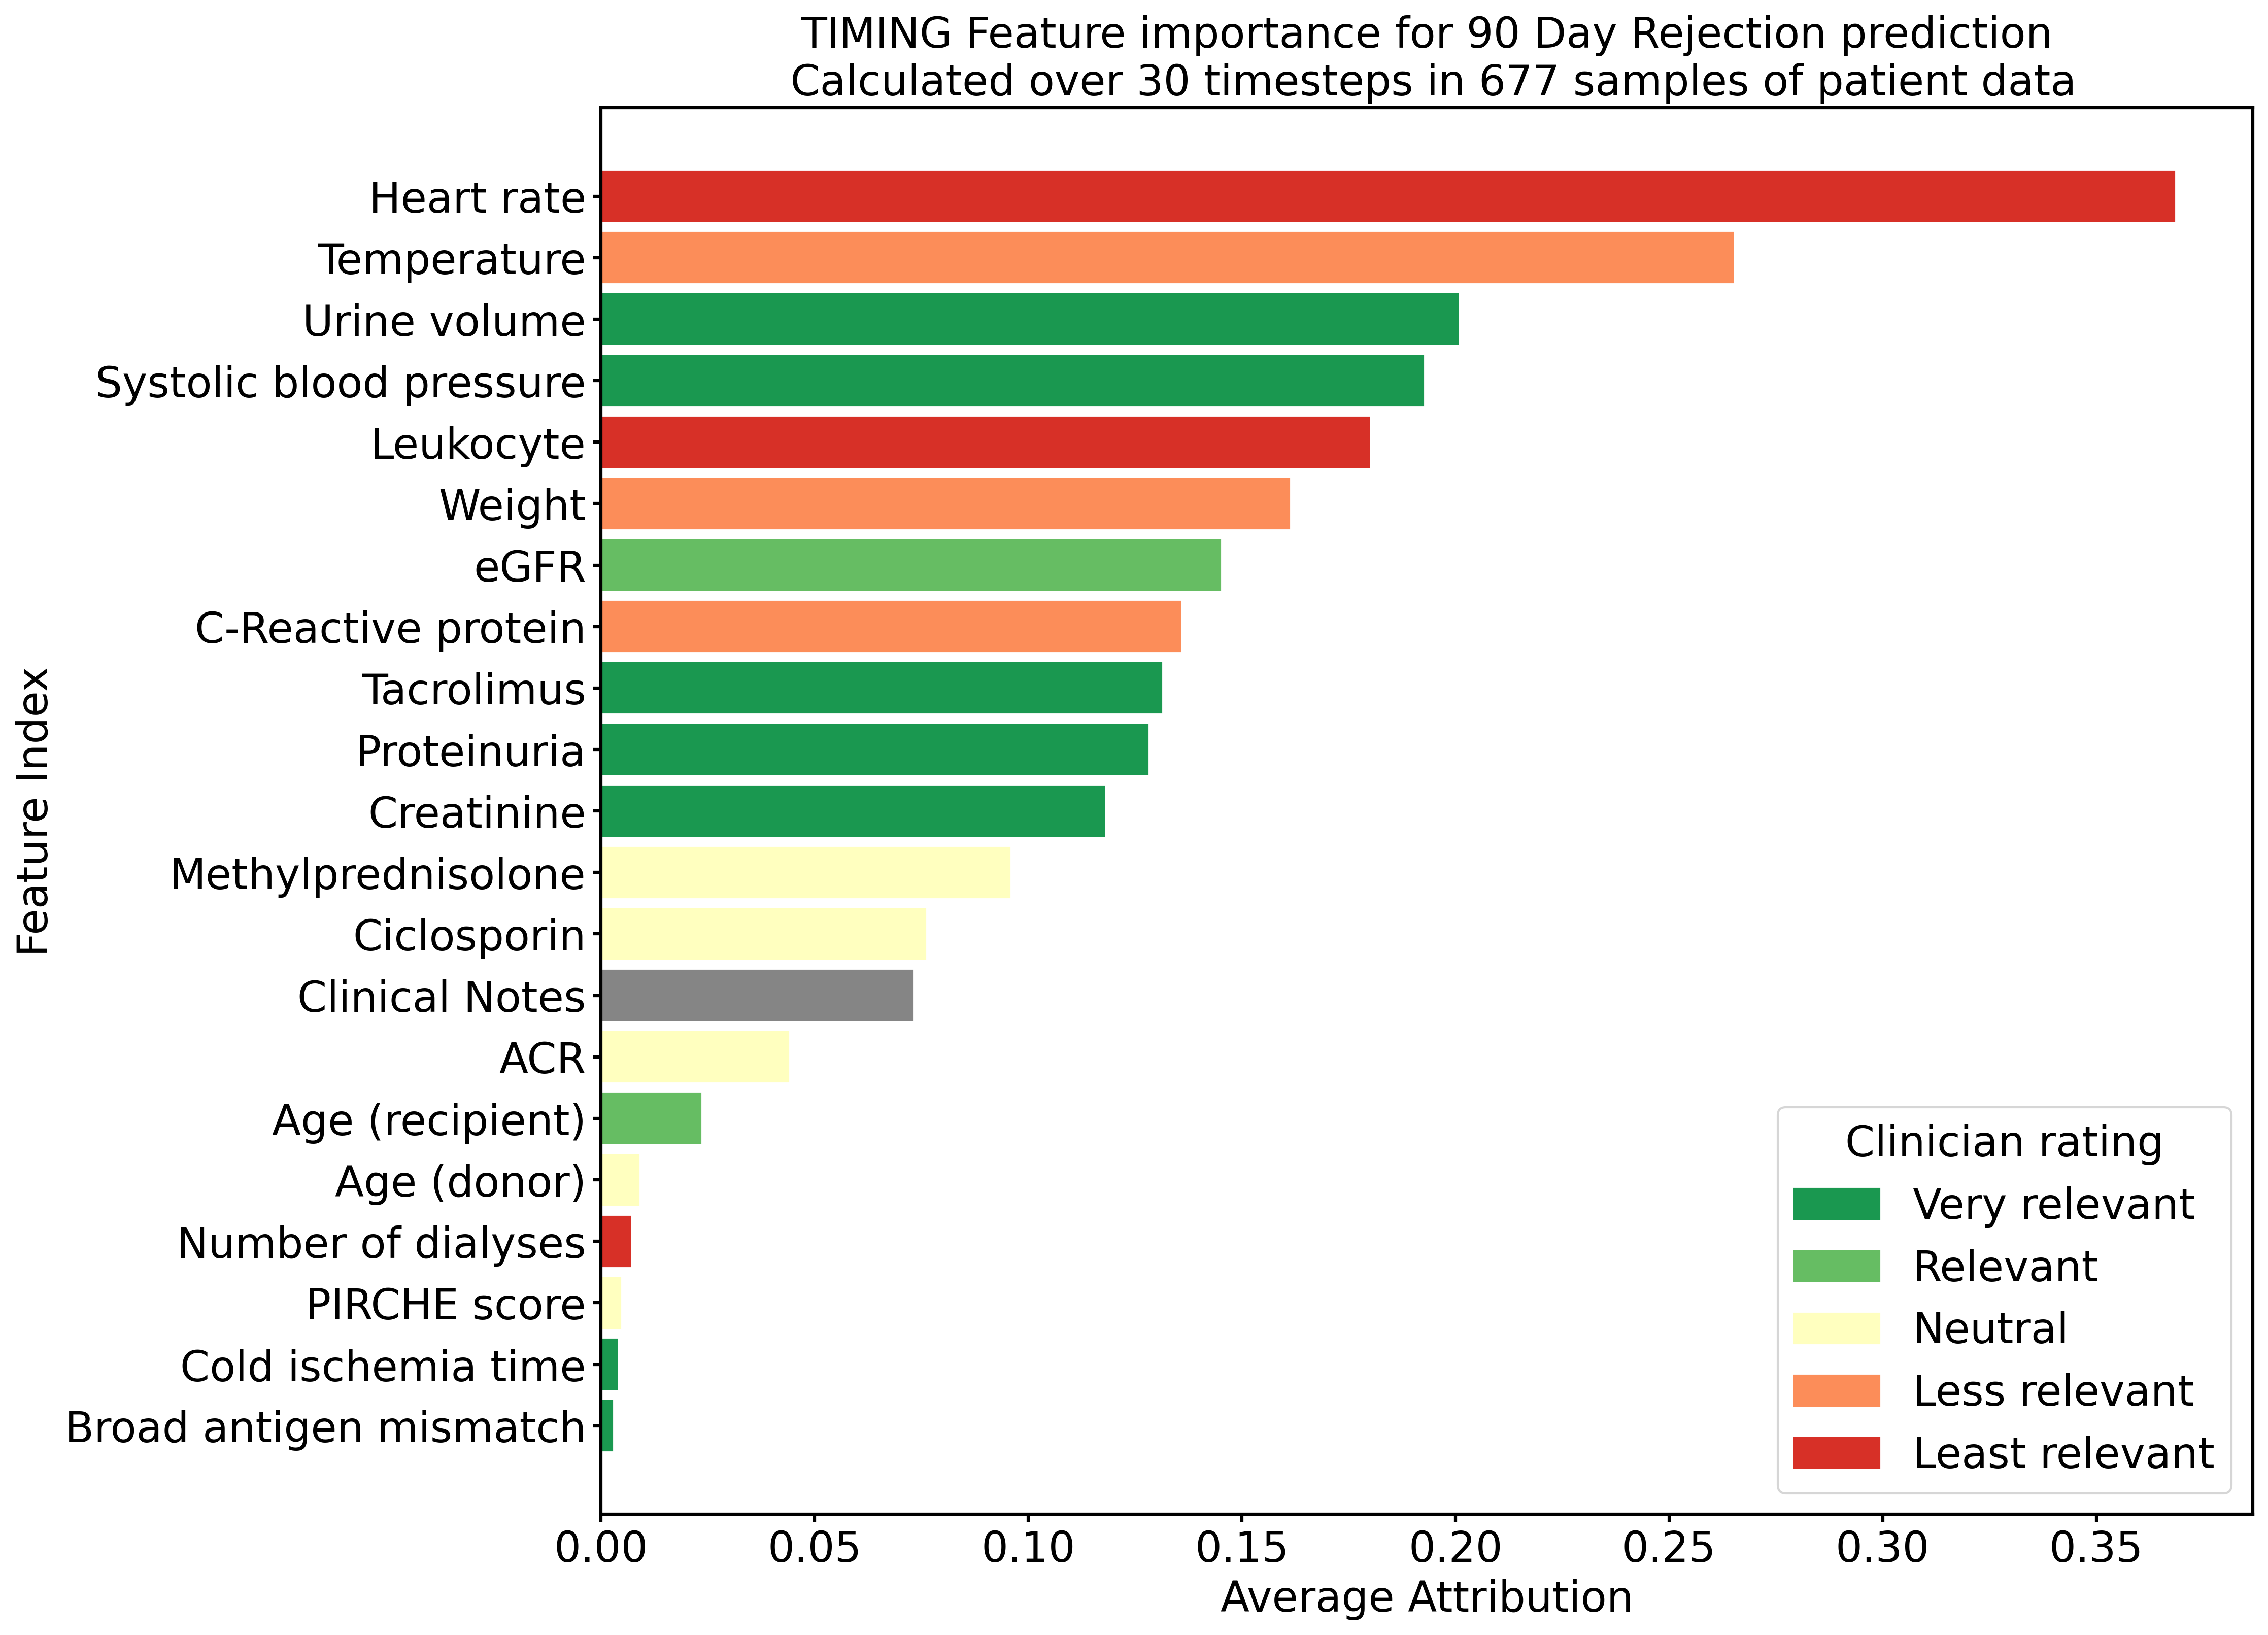

                    Feature  IG Score  Clinical Rating
0    Broad antigen mismatch  0.002630                1
1        Cold ischemia time  0.003685                1
2              PIRCHE score  0.004500                3
3        Number of dialyses  0.006772                5
4               Age (donor)  0.008824                3
5           Age (recipient)  0.023323                2
6                       ACR  0.043867                3
7            Clinical Notes  0.072880                0
8               Ciclosporin  0.075900                3
9        Methylprednisolone  0.095652                3
10               Creatinine  0.117702                1
11              Proteinuria  0.127866                1
12               Tacrolimus  0.131176                1
13       C-Reactive protein  0.135521                4
14                     eGFR  0.144956                2
15                   Weight  0.161003                4
16                Leukocyte  0.179659                5
17  Systol

In [71]:
#%%script false --no-raise-error
#Plot 
# Set global font sizes
plt.rcParams.update({
    'font.size': 20,              # Base font size
    'axes.titlesize': 20,         # Title font size
    'axes.labelsize': 20,         # Axes label font size
    'xtick.labelsize': 20,        # X-tick label font size
    'ytick.labelsize': 20,        # Y-tick label font size
    'legend.fontsize': 20,        # Legend font size
    'figure.titlesize': 20,       # Figure title size
    'figure.dpi': 300,            # Figure DPI for high resolution
    'savefig.dpi': 300            # Save figure DPI
})

# Make lines thicker
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5

# Increase marker size default
plt.rcParams['lines.markersize'] = 8

likert_scale = {
    1: "Very relevant",
    2: "Relevant",
    3: "Neutral",
    4: "Less relevant",
    5: "Least relevant"
}

feature_name_mapping = {
    'age': 'Age (recipient)',
    'Age': 'Age (recipient)',

    'gender': 'Gender (recipient)',
    'underlying_disease': 'Underlying disease',
    'blood_group': 'Blood group (recipient)',
    'cold_ischemia_time': 'Cold ischemia time',
    'gender_donor': 'Gender (donor)',
    'age_donor': 'Age (donor)',
    'donor_bloodgroup': 'Blood group (donor)',
    'type_of_donation': 'Type of donation',
    'pirche_score': 'PIRCHE score',
    'mm_broad': 'Broad antigen mismatch',
    'mma_broad': 'A Broad antigen mismatch',
    'mmdr_broad': 'DR Broad antigen mismatch',
    'mmb_broad': 'B Broad antigen mismatch',
    'hr': 'Heart rate',
    'Blood pressure': 'Blood pressure',
    'bp_sys': 'Systolic blood pressure',
    'bp_dia': 'Diastolic blood pressure',
    'weight': 'Weight',
    'temperature': 'Temperature',
    'urine_volume': 'Urine volume',
    'creatinine': 'Creatinine',
    'leukocyte': 'Leukocyte',
    'crphp': 'C-Reactive protein',
    'proteinuria': 'Proteinuria',
    'acr': 'ACR',
    'ACR': 'ACR',
    'egfr': 'eGFR',
    'Tacrolimus': 'Tacrolimus',
    'Methylprednisolon': 'Methylprednisolone',
    'Ciclosporin': 'Ciclosporin',
    'number_dialyses': 'Number of dialyses',
    'diuresis_time': 'Diuresis time',
    #'Notes embeddings': 'Clinical Notes',
    'Underlying disease': 'Underlying disease',
    #'notes_embedding_mean': 'Clinical Notes',
    'notes_embedding_mean' : 'Clinical Notes'
}


reverse_feature_name_mapping = {}
for k, v in feature_name_mapping.items():
    if v not in reverse_feature_name_mapping:
        reverse_feature_name_mapping[v] = k

feature_names = (
    CONFIG['static_numerical_cols'] +
    CONFIG['ts_features'] +
    ['notes_embedding_mean']
)

colors = ['#1a9850', '#66bd63', '#ffffbf', '#fc8d59', '#d73027', "#858585"]
scores = []
names = []
importance = []

num_samples=677
T=30
version = "TIMING" #TIMING or IG
task = "Rejection" # "Graft Loss" or "Rejection" or "Mortality"
path = f"../results/{version}_{task.replace(' ', '_')}_feature_importance_{num_samples}samples_T{T}"

if task == "GraftLoss":
    feature_importance = {'hr': 5, 'gender': 5, 'gender_donor': 5, 'temperature': 5, 'leukocyte': 5, 'donor_bloodgroup': 4, 'number_dialyses': 4, 'Methylprednisolon': 4, 'blood_group': 4, 'bp_sys': 4, 'crphp': 3, 'Ciclosporin': 3, 'weight': 3, 'pirche_score': 3, 'age': 3, 'age_donor': 2, 'cold_ischemia_time': 2, 'Tacrolimus': 2, 'proteinuria': 2, 'acr': 2, 'type_of_donation': 1, 'mm_broad': 1, 'mma_broad': 1, 'mmdr_broad': 1, 'mmb_broad': 1, 'urine_volume': 1, 'egfr': 1, 'creatinine': 1, "notes_embedding_mean": 0}
if task == "Mortality":
    feature_importance = {'hr': 1, 'gender': 4, 'gender_donor': 5, 'temperature': 1, 'leukocyte': 2, 'donor_bloodgroup': 5, 'number_dialyses': 2, 'Methylprednisolon': 4, 'blood_group': 5, 'bp_sys': 1, 'crphp': 1, 'Ciclosporin': 4, 'weight': 3, 'pirche_score': 4, 'age': 1, 'age_donor': 2, 'cold_ischemia_time': 4, 'Tacrolimus': 4, 'proteinuria': 3, 'acr': 3, 'type_of_donation': 3, 'mm_broad': 4, 'mma_broad': 4, 'mmdr_broad': 4, 'mmb_broad': 4, 'urine_volume': 3, 'egfr': 2, 'creatinine': 2, "notes_embedding_mean": 0}
if task == "Rejection":
    feature_importance = {'hr': 5, 'gender': 3, 'gender_donor': 4, 'temperature': 4, 'leukocyte': 5, 'donor_bloodgroup': 3, 'number_dialyses': 5, 'Methylprednisolon': 3, 'blood_group': 3, 'bp_sys': 1, 'crphp': 4, 'Ciclosporin': 3, 'weight': 4, 'pirche_score': 3, 'age': 2, 'age_donor': 3, 'cold_ischemia_time': 1, 'Tacrolimus': 1, 'proteinuria': 1, 'acr': 3, 'type_of_donation': 1, 'mm_broad': 1, 'mma_broad': 1, 'mmdr_broad': 1, 'mmb_broad': 1, 'urine_volume': 1, 'egfr': 2, 'creatinine': 1, "notes_embedding_mean": 0}



with open(f"{path}.json", "r") as f:
    tmp = json.load(f)
    for entry in tmp:
        scores.append(entry['IG Value'])
        name = entry['Feature']
        names.append(name)
        importance.append(feature_importance[reverse_feature_name_mapping[name]])

plt.figure(figsize=(14,12))
bars = plt.barh(range(len(scores)), scores)  # convert to numpy for matplotlib

plt.ylabel("Feature Index")
plt.xlabel("Average Attribution")
plt.title(f"{version} Feature importance for 90 Day {task} prediction\n Calculated over {T} timesteps in {num_samples} samples of patient data")
plt.yticks(range(len(names)), names)
sorted_importance = []
for i in range(0, len(importance)):
    color = colors[importance[i]-1]
    bars[i].set_color(color)

legend_elements = [plt.Rectangle((0, 0), 1, 1, color=colors[i], label=list(likert_scale.values())[i]) for i in range(0, 5)]
plt.legend(handles=legend_elements, loc='lower right', title="Clinician rating")
plt.savefig(f"{path}.jpg", dpi=300, bbox_inches="tight")
plt.show()

ig_df = pd.DataFrame({
    'Feature': names,
    'IG Score': scores,
    'Clinical Rating': importance
})

print(ig_df)

                    Feature  IG Score  SHAP Score  Clinical Rating
1    Broad antigen mismatch  0.002630       0.024                1
2              Urine volume  0.200462       0.011                1
3   Systolic blood pressure  0.192420       0.021                1
4                Tacrolimus  0.131176       0.071                1
5               Proteinuria  0.127866       0.036                1
6                Creatinine  0.117702       0.122                1
7        Cold ischemia time  0.003685       0.014                1
8           Age (recipient)  0.023323       0.043                2
9                      eGFR  0.144956       0.088                2
10              Ciclosporin  0.075900       0.065                3
11       Methylprednisolone  0.095652       0.042                3
12              Age (donor)  0.008824       0.023                3
13             PIRCHE score  0.004500       0.017                3
14                      ACR  0.043867       0.016             

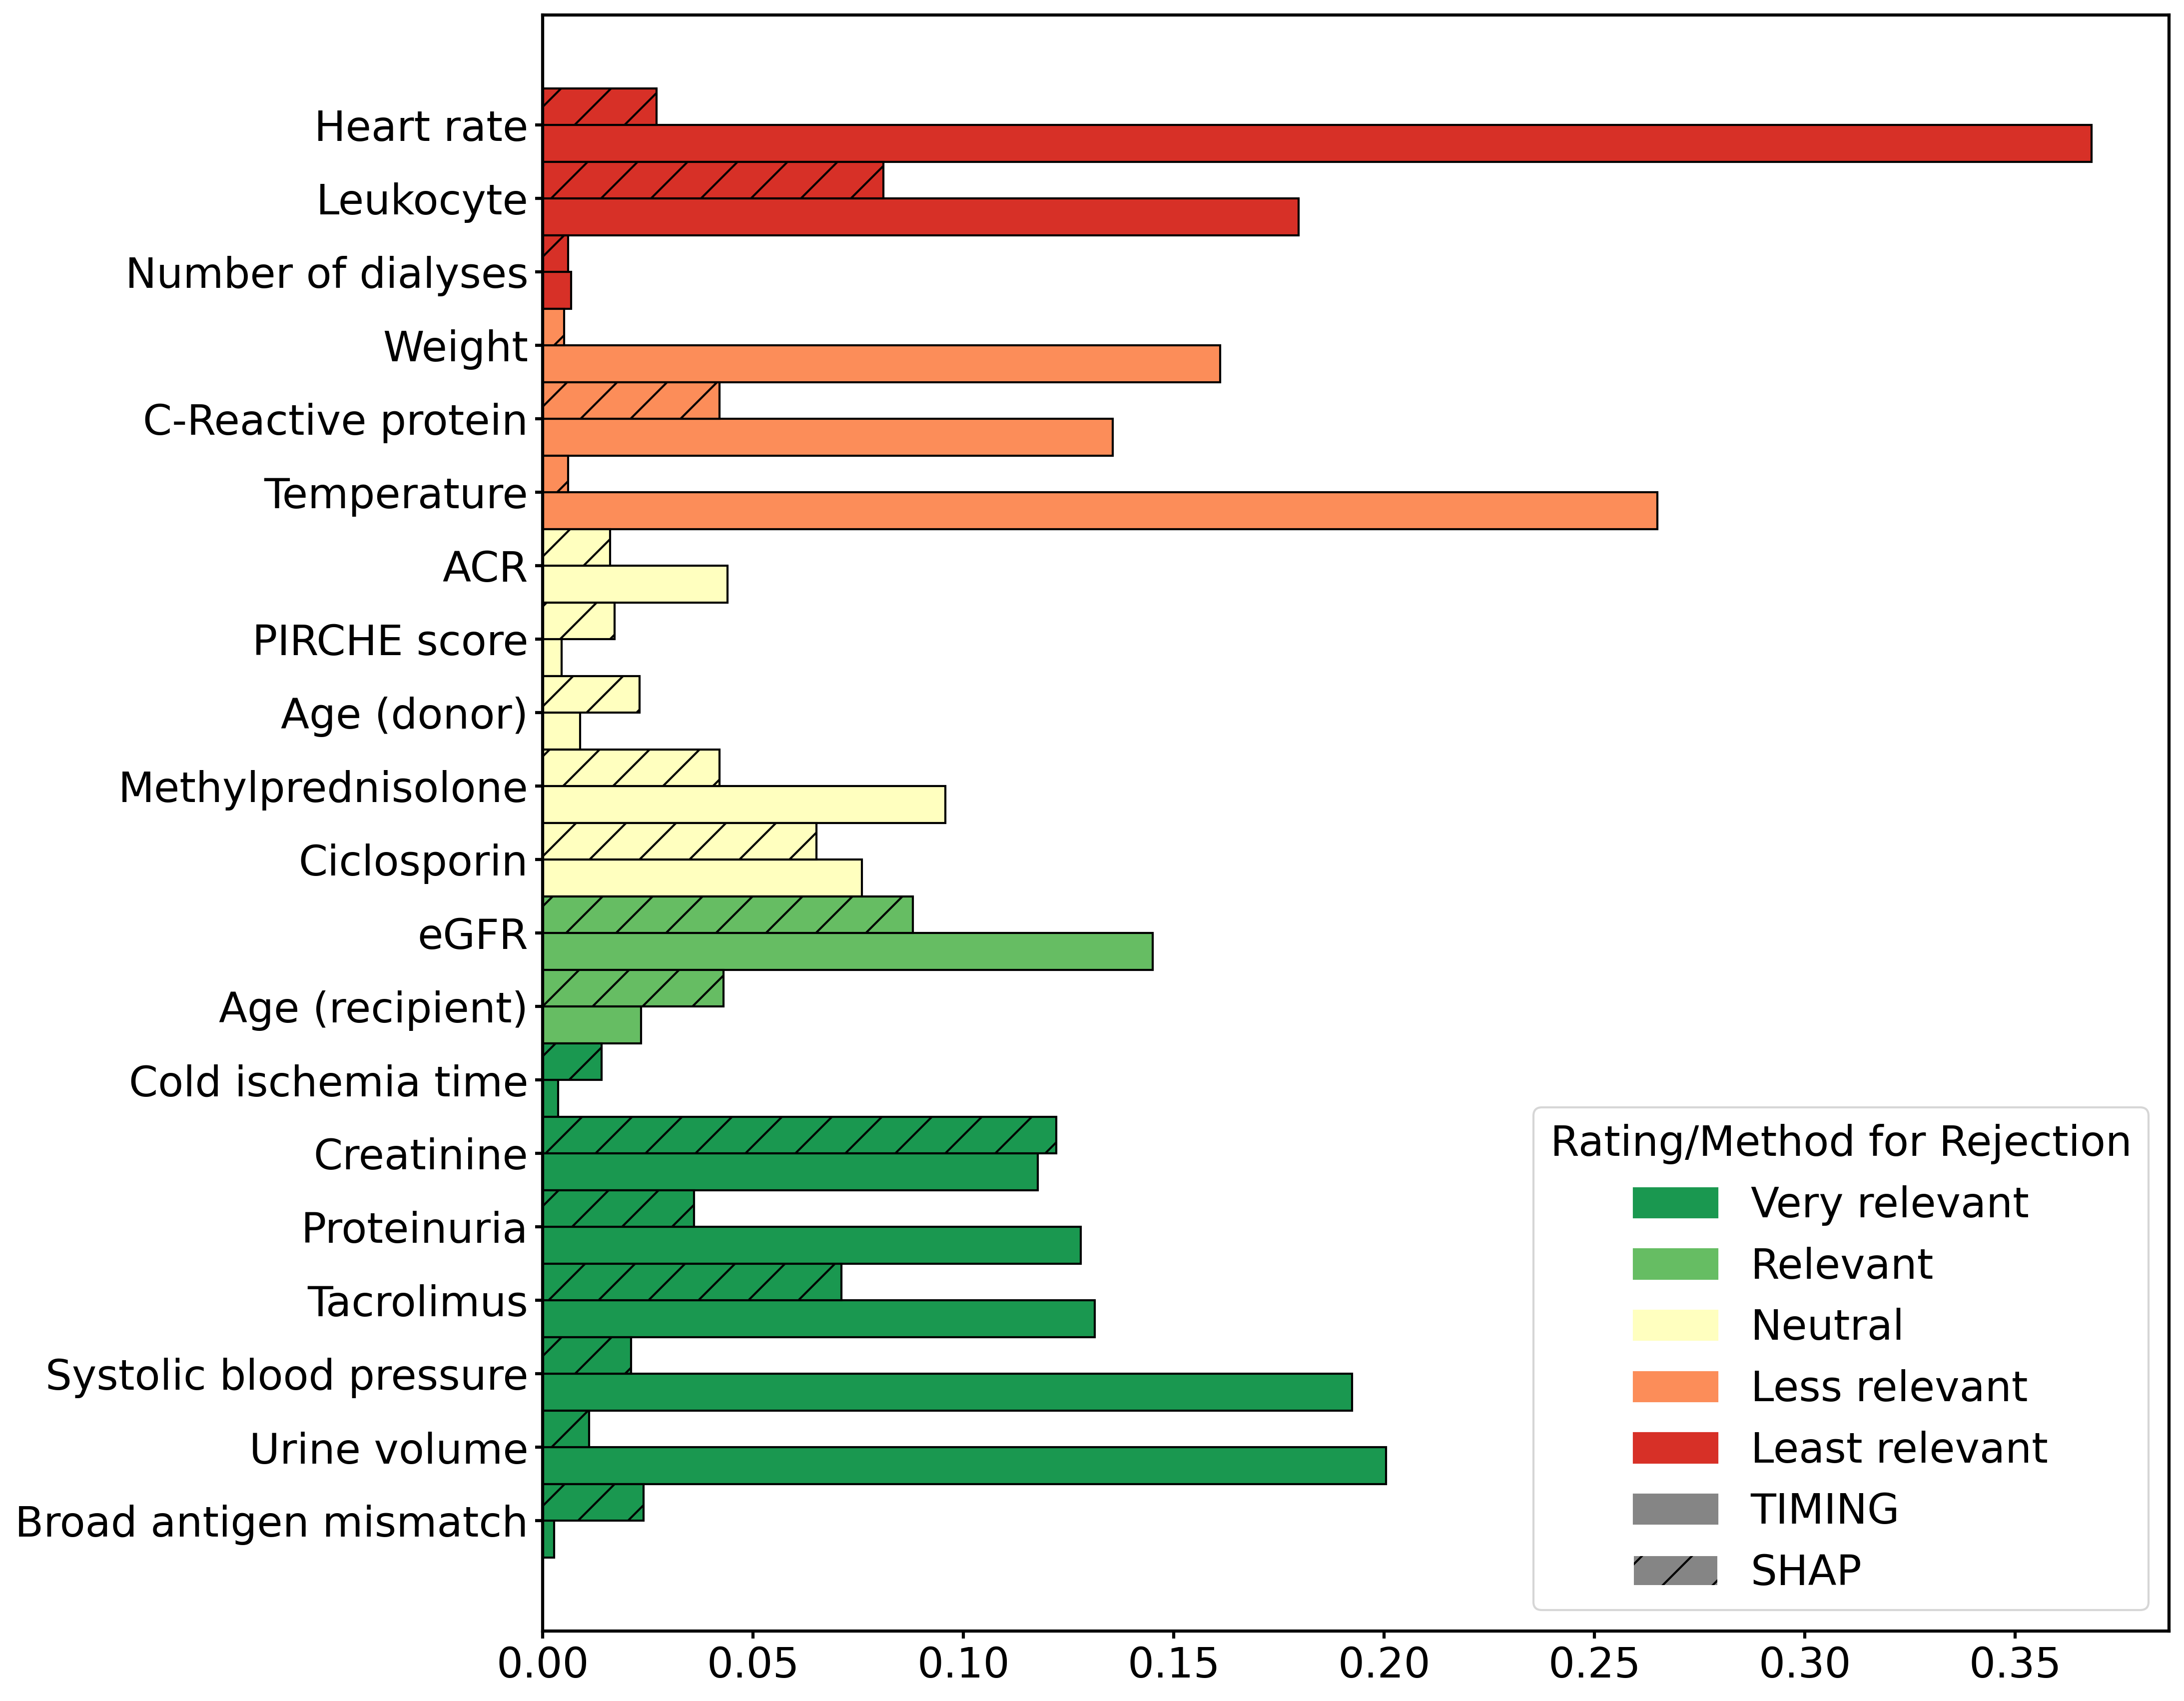

In [72]:
from scipy import stats
from sklearn import metrics

shap_data = {'Graft Loss': {'Creatinine': 0.129,
  'eGFR': 0.083,
  'Tacrolimus': 0.046,
  'Proteinuria': 0.045,
  'Ciclosporin': 0.042,
  'ACR': 0.038,
  'Leukocyte': 0.032,
  'Blood pressure': 0.027,
  'crphp': 0.026,
  'urine_volume': 0.015,
  'bp_sys': 0.024,
  'Methylprednisolon': 0.013,
  'temperature': 0.006,
  'diuresis_time': 0.018,
  'hr': 0.017,
  'weight': 0.008,
  'mm_broad': 0.012,
  'type_of_donation': 0.012,
  'number_dialyses': 0.014,
  'gender': 0.008,
  'Notes embeddings': 0.048,
  'donor_bloodgroup': 0.006,
  'blood_group': 0.005,
  'pirche_score': 0.017,
  'underlying_disease': 0.032,
  'Age': 0.03,
  'age_donor': 0.023,
  'cold_ischemia_time': 0.013,
  'gender_donor': 0.003},
 'Rejection': {'Creatinine': 0.122,
  'Leukocyte': 0.081,
  'Tacrolimus': 0.071,
  'Ciclosporin': 0.065,
  'eGFR': 0.088,
  'crphp': 0.042,
  'Methylprednisolon': 0.042,
  'Proteinuria': 0.036,
  'Heart rate': 0.027,
  'mm_broad': 0.024,
  'bp_dia': 0.023,
  'bp_sys': 0.021,
  'temperature': 0.006,
  'urine_volume': 0.011,
  'pirche_score': 0.017,
  'acr': 0.016,
  'type_of_donation': 0.015,
  'diuresis_time': 0.014,
  'weight': 0.005,
  'Notes embeddings': 0.07,
  'gender': 0.008,
  'blood_group': 0.005,
  'donor_bloodgroup': 0.004,
  'number_dialyses': 0.006,
  'underlying_disease': 0.004,
  'Age': 0.043,
  'age_donor': 0.023,
  'cold_ischemia_time': 0.014,
  'gender_donor': 0.003},
 'Mortality': {'Age': 0.11,
  'Creatinine': 0.083,
  'eGFR': 0.068,
  'Leukocyte': 0.05,
  'Heart rate': 0.045,
  'Ciclosporin': 0.035,
  'bp_sys': 0.03,
  'bp_dia': 0.011,
  'Tacrolimus': 0.025,
  'Proteinuria': 0.022,
  'crphp': 0.02,
  'Underlying disease': 0.02,
  'Temperature': 0.004,
  'weight': 0.008,
  'Methylprednisolon': 0.014,
  'urine_volume': 0.009,
  'gender': 0.012,
  'diuresis_time': 0.01,
  'number_dialyses': 0.01,
  'age_donor': 0.009,
  'acr': 0.017,
  'type_of_donation': 0.006,
  'Notes embeddings': 0.005,
  'donor_bloodgroup': 0.004,
  'blood_group': 0.004,
  'mm_broad': 0.003,
  'gender_donor': 0.002,
  'pirche_score': 0.001,
  'cold_ischemia_time': 0.001}}


plt.figure(figsize=(14,14))
shap_score = []
df = ig_df
for name, value in shap_data[task].items():
    df.loc[df['Feature'] == (feature_name_mapping[name] if feature_name_mapping.get(name) else name), 'SHAP Score'] = value
df = df.iloc[:, [0, 1, 3, 2]]
df = df.sort_values("Clinical Rating", ascending=True, ignore_index=True)
df = df.drop(0, axis="index")
print(df)

shap_spearman = stats.spearmanr(df['SHAP Score'], df['Clinical Rating'].sub(6).abs())
ig_spearman = stats.spearmanr(df['IG Score'], df['Clinical Rating'].sub(6).abs())
print(f"Spearman correlation of - SHAP: C:{shap_spearman.correlation.item()}, P:{shap_spearman.pvalue.item()}, {version}: C:{ig_spearman.correlation}, P:{ig_spearman.pvalue}")
k = len(feature_importance)-1
shap_ndcg = metrics.ndcg_score([df['Clinical Rating'].sub(6).abs()], [df['SHAP Score']], k=k)
IG_ndcg = metrics.ndcg_score([df['Clinical Rating'].sub(6).abs()], [df['IG Score']], k=k)

print(f"NDCG Score of - SHAP: {shap_ndcg}, {version}: {IG_ndcg}")

y_pos = np.arange(len(df))
bar_height = 0.5

# First bar (x)
ig_bars = plt.barh(y_pos - bar_height/2, df["IG Score"], 
         label="x", height=bar_height)

# Second bar (y)
shap_bars = plt.barh(y_pos + bar_height/2, df["SHAP Score"], 
         label="y", height=bar_height, hatch="/")
importance = list(df['Clinical Rating'])
for i in range(0, len(importance)):
    color = colors[importance[i]-1]
    ig_bars[i].set_facecolor(color)
    shap_bars[i].set_facecolor(color)
    ig_bars[i].set_edgecolor("black")
    shap_bars[i].set_edgecolor("black")
legend_elements = [plt.Rectangle((0, 0), 1, 1, color=colors[i], label=list(likert_scale.values())[i]) for i in range(0, 5)]
legend_elements.append(plt.Rectangle((0, 0), 1, 1, color=colors[-1], label=version))
legend_elements.append(plt.Rectangle((0, 0), 1, 1, facecolor=colors[-1], hatch="/", label="SHAP"))

#legend_elements.append(("/", "SHAP"))
plt.legend(handles=legend_elements, loc='lower right', title=f"Rating/Method for {task}")
plt.yticks(y_pos, df["Feature"])
plt.show()